# Employee Attrition Analysis
## Dicoding Data Science — Task 1

**Problem Statement:**  
Analyze and identify the critical factors that influence employee attrition using the provided dataset.

**Workflow:**
1. Data Understanding
2. Exploratory Data Analysis (EDA)
3. Data Preprocessing
4. Modeling
5. Evaluation
6. Feature Importance Analysis

---
## 1. Import Libraries

In [1]:
# Core libraries
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

# Evaluation
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, accuracy_score, f1_score, ConfusionMatrixDisplay
)

# Style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
pd.set_option('display.max_columns', 50)

print('Libraries imported successfully!')

Libraries imported successfully!


---
## 2. Data Understanding

In [2]:
# Load dataset
df = pd.read_csv('employee_data.csv')
print(f'Dataset shape: {df.shape}')
print(f'Number of features: {df.shape[1]}')
print(f'Number of samples: {df.shape[0]}')

Dataset shape: (1470, 35)
Number of features: 35
Number of samples: 1470


In [3]:
# Preview
df.head()

,EmployeeId,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,1,38,NaN,Travel_Frequently,1444,Human Resources,1,4,Other,1,4,Male,88,3,1,Human Resources,2,Married,2991,5224,0,Y,Yes,11,3,2,80,1,7,2,3,6,2,1,2
1,2,37,1.0,Travel_Rarely,1141,Research & Development,11,2,Medical,1,1,Female,61,1,2,Healthcare Representative,2,Married,4777,14382,5,Y,No,15,3,1,80,0,15,2,1,1,0,0,0
2,3,51,1.0,Travel_Rarely,1323,Research & Development,4,4,Life Sciences,1,1,Male,34,3,1,Research Scientist,3,Married,2461,10332,9,Y,Yes,12,3,3,80,3,18,2,4,10,0,2,7
3,4,42,0.0,Travel_Frequently,555,Sales,26,3,Marketing,1,3,Female,77,3,4,Sales Executive,2,Married,13525,14864,5,Y,No,14,3,4,80,1,23,2,4,20,4,4,8
4,5,40,NaN,Travel_Rarely,1194,Research & Development,2,4,Medical,1,3,Female,98,3,1,Research Scientist,3,Married,2001,12549,2,Y,No,14,3,2,80,3,20,2,3,5,3,0,2


In [4]:
# Data info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   EmployeeId                1470 non-null   int64  
 1   Age                       1470 non-null   int64  
 2   Attrition                 1058 non-null   float64
 3   BusinessTravel            1470 non-null   str    
 4   DailyRate                 1470 non-null   int64  
 5   Department                1470 non-null   str    
 6   DistanceFromHome          1470 non-null   int64  
 7   Education                 1470 non-null   int64  
 8   EducationField            1470 non-null   str    
 9   EmployeeCount             1470 non-null   int64  
 10  EnvironmentSatisfaction   1470 non-null   int64  
 11  Gender                    1470 non-null   str    
 12  HourlyRate                1470 non-null   int64  
 13  JobInvolvement            1470 non-null   int64  
 14  JobLevel           

In [5]:
# Statistical summary
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
EmployeeId,1470.0,NaN,NaN,NaN,735.5,424.496761,1.0,368.25,735.5,1102.75,1470.0
Age,1470.0,NaN,NaN,NaN,36.92381,9.135373,18.0,30.0,36.0,43.0,60.0
Attrition,1058.0,NaN,NaN,NaN,0.169187,0.375094,0.0,0.0,0.0,0.0,1.0
BusinessTravel,1470,3,Travel_Rarely,1043,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DailyRate,1470.0,NaN,NaN,NaN,802.485714,403.5091,102.0,465.0,802.0,1157.0,1499.0
Department,1470,3,Research & Development,961,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DistanceFromHome,1470.0,NaN,NaN,NaN,9.192517,8.106864,1.0,2.0,7.0,14.0,29.0
Education,1470.0,NaN,NaN,NaN,2.912925,1.024165,1.0,2.0,3.0,4.0,5.0
EducationField,1470,6,Life Sciences,606,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EmployeeCount,1470.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0


In [6]:
# Missing values analysis
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing (%)': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing (%)', ascending=False)
print('Columns with missing values:')
display(missing_df)

Columns with missing values:


,Missing Count,Missing (%)
Attrition,412,28.027211


In [7]:
# Target variable distribution
attrition_counts = df['Attrition'].value_counts(dropna=False)
print('Attrition value distribution:')
print(attrition_counts)
print(f"\nLabeled rows (0.0 or 1.0): {df['Attrition'].notna().sum()}")
print(f"Unlabeled rows (NaN): {df['Attrition'].isna().sum()}")

Attrition value distribution:
Attrition
0.0    879
NaN    412
1.0    179
Name: count, dtype: int64

Labeled rows (0.0 or 1.0): 1058
Unlabeled rows (NaN): 412


In [8]:
# Separate labeled vs unlabeled data
df_labeled = df[df['Attrition'].notna()].copy()
df_unlabeled = df[df['Attrition'].isna()].copy()

print(f'Labeled (train/test) samples: {len(df_labeled)}')
print(f'Unlabeled samples: {len(df_unlabeled)}')
print(f"\nAttrition rate (labeled): {df_labeled['Attrition'].mean()*100:.1f}%")

Labeled (train/test) samples: 1058
Unlabeled samples: 412

Attrition rate (labeled): 16.9%


In [9]:
# Identify constant / useless columns
constant_cols = [col for col in df.columns if df[col].nunique() <= 1]
print('Constant columns (to be removed):', constant_cols)

# Unique check for near-constant
for col in ['EmployeeCount', 'StandardHours', 'Over18']:
    print(f'{col}: unique values = {df[col].unique()}')

Constant columns (to be removed): ['EmployeeCount', 'Over18', 'StandardHours']
EmployeeCount: unique values = [1]
StandardHours: unique values = [80]
Over18: unique values = <StringArray>
['Y']
Length: 1, dtype: str


---
## 3. Exploratory Data Analysis (EDA)

### 3.1 Target Variable — Attrition Distribution

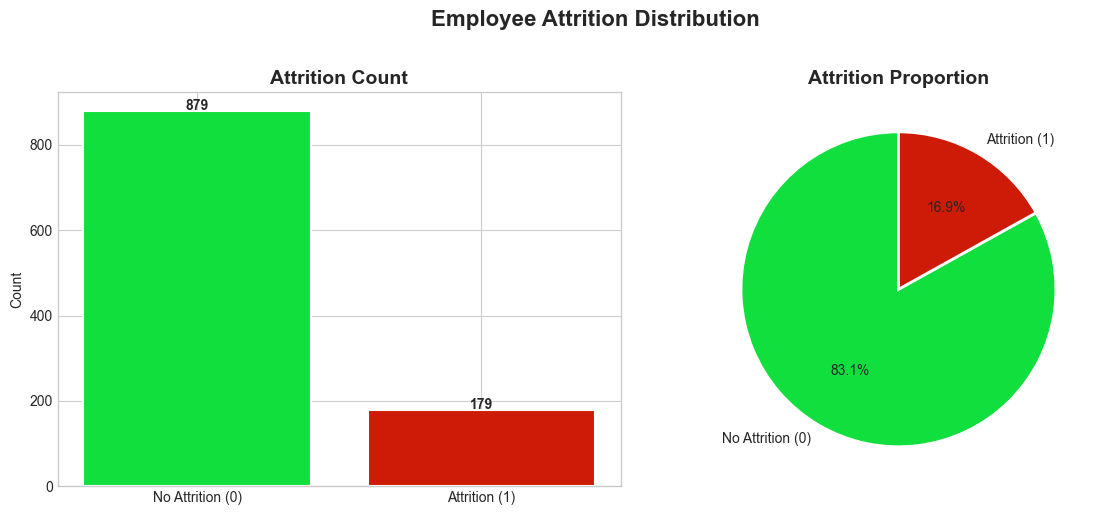

Class imbalance ratio — No Attrition : Attrition = 879:179 (4.9:1)


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
counts = df_labeled['Attrition'].value_counts()
labels = ['No Attrition (0)', 'Attrition (1)']
colors = ["#11df3e", "#ce1b07"]

axes[0].bar(labels, counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Attrition Count', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 3, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=labels, colors=colors, autopct='%1.1f%%',
            startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Attrition Proportion', fontsize=14, fontweight='bold')

plt.suptitle('Employee Attrition Distribution', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot_attrition_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"Class imbalance ratio — No Attrition : Attrition = {counts[0.0]}:{counts[1.0]} ({counts[0.0]/counts[1.0]:.1f}:1)")

### 3.2 Numerical Features Distribution

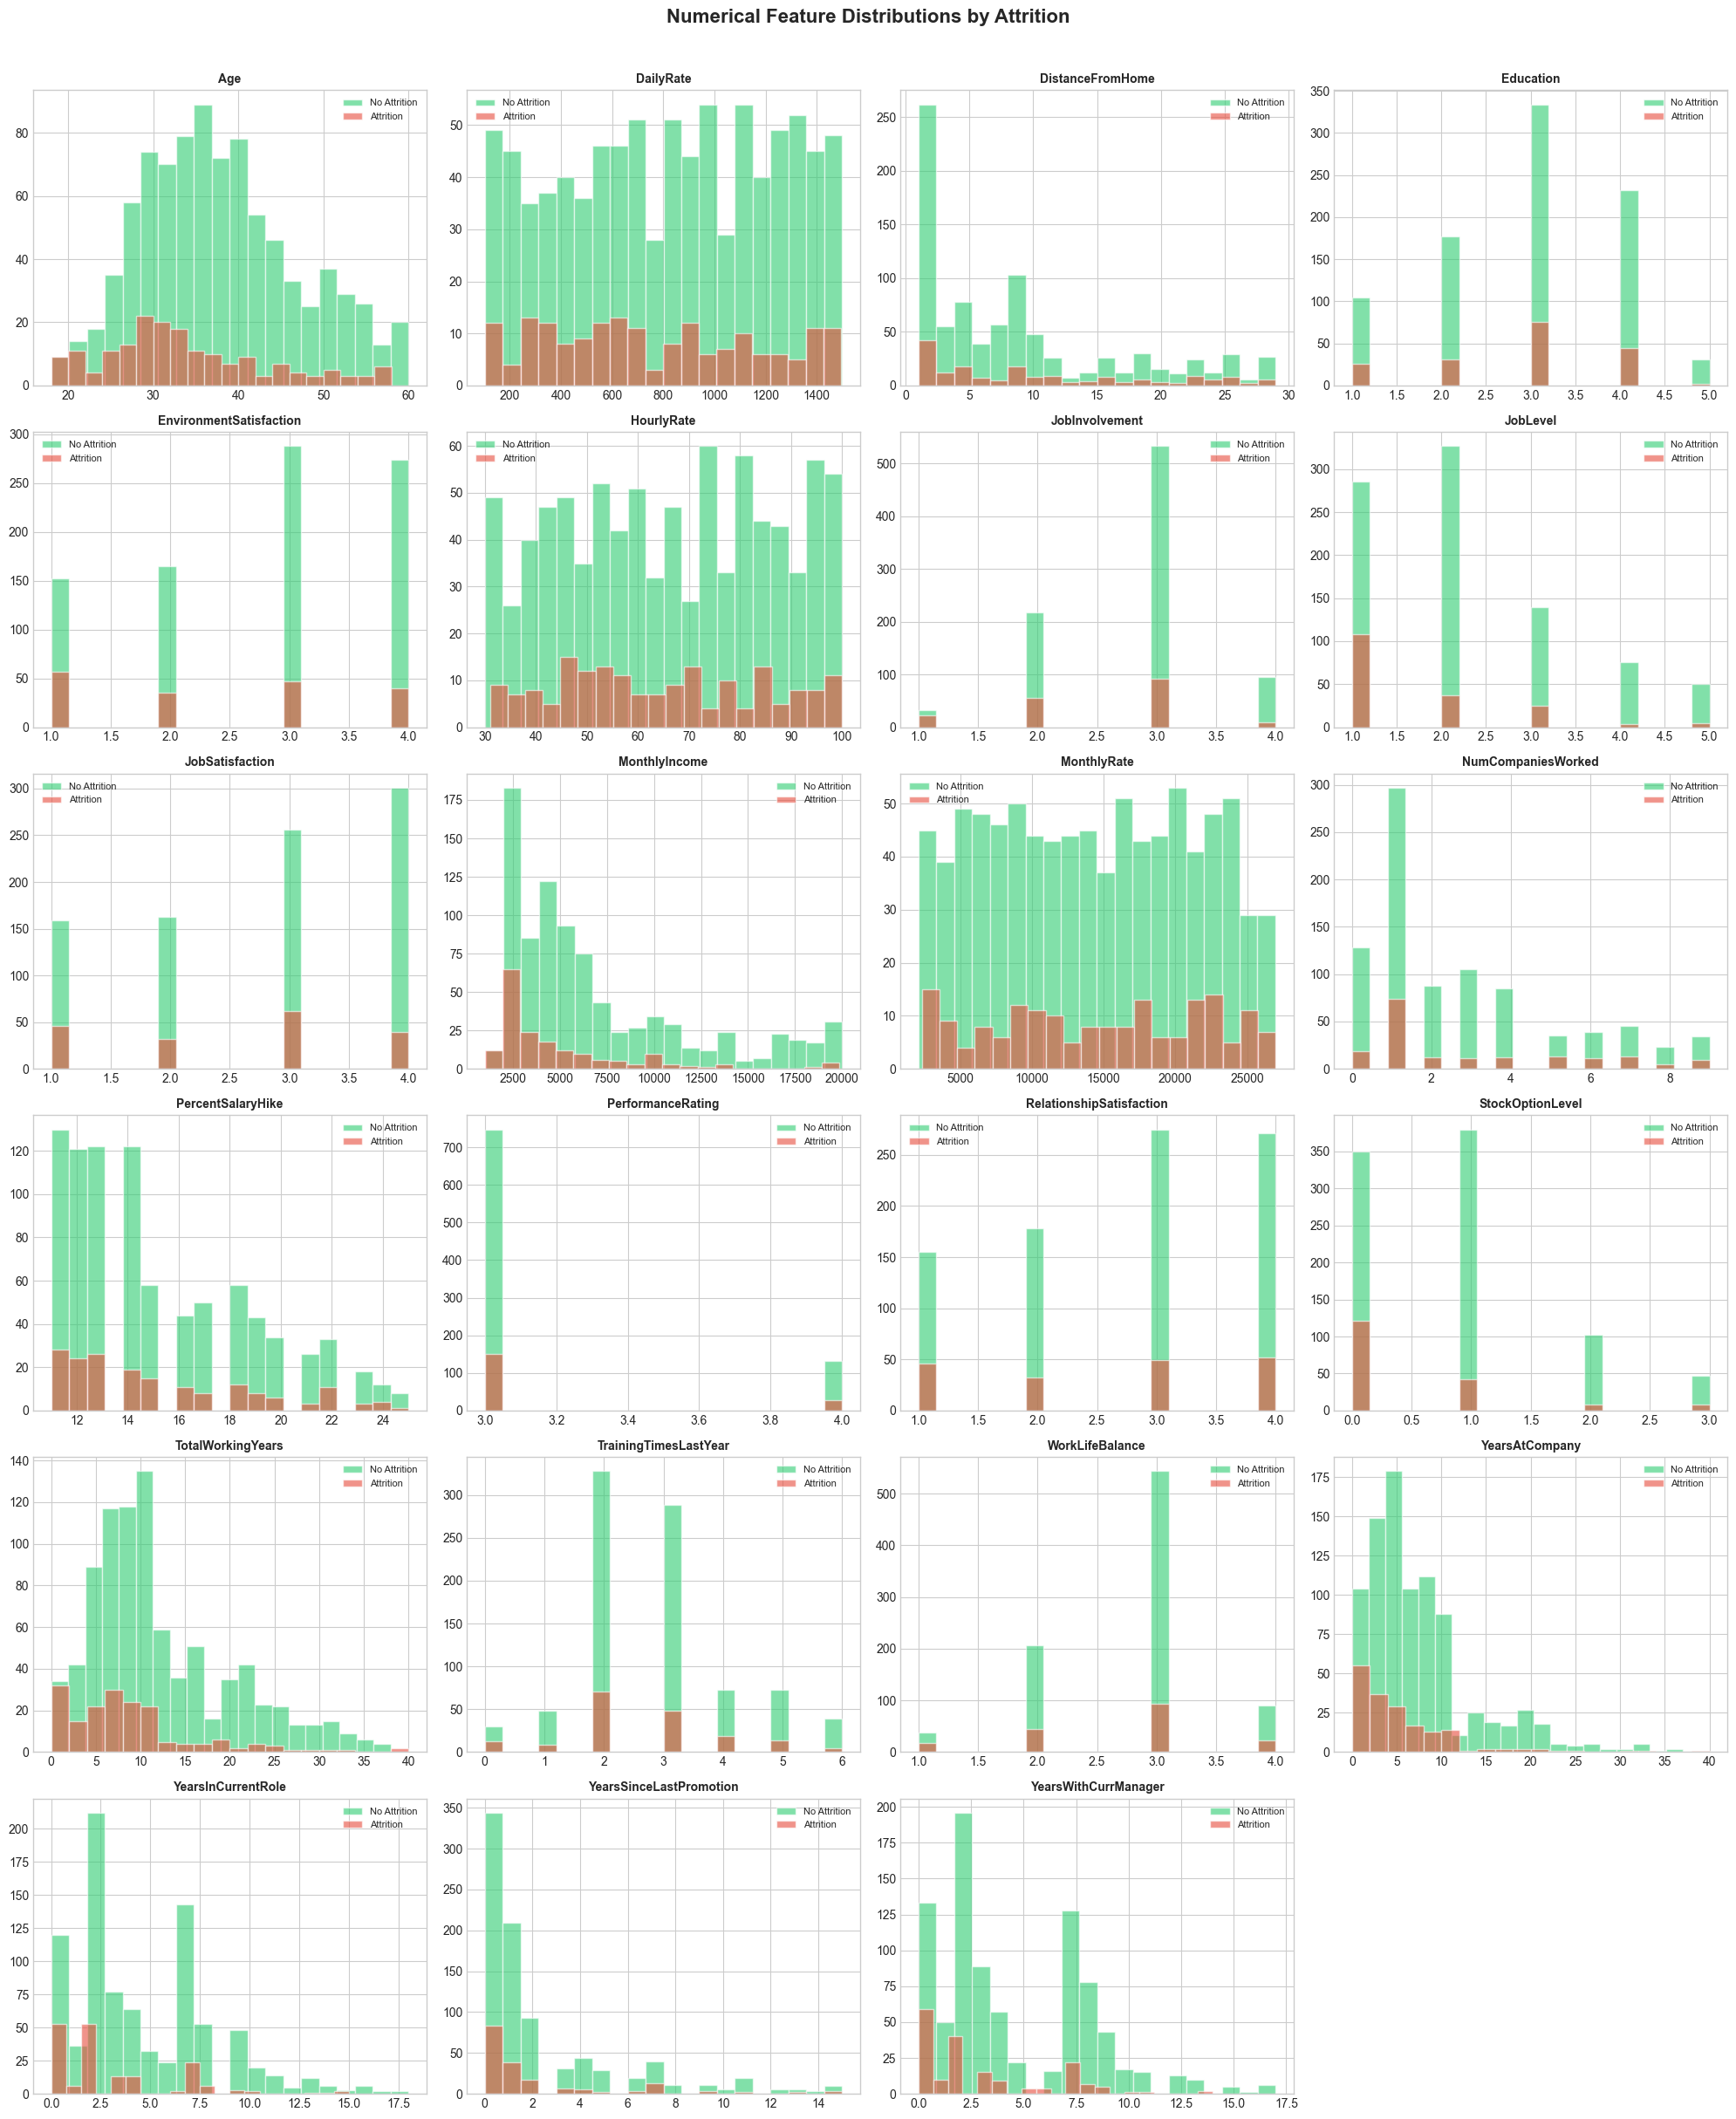

In [11]:
num_cols = df_labeled.select_dtypes(include=['float64', 'int64']).columns.tolist()
num_cols = [c for c in num_cols if c not in ['EmployeeId', 'EmployeeCount', 'StandardHours', 'Attrition']]

n = len(num_cols)
ncols = 4
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(20, nrows * 4))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    for val, color, label in [(0.0, '#2ecc71', 'No Attrition'), (1.0, '#e74c3c', 'Attrition')]:
        subset = df_labeled[df_labeled['Attrition'] == val][col]
        axes[i].hist(subset, bins=20, alpha=0.6, color=color, label=label, edgecolor='white')
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].legend(fontsize=8)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numerical Feature Distributions by Attrition', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot_numeric_distributions.png', dpi=100, bbox_inches='tight')
plt.show()

### 3.3 Categorical Features vs Attrition

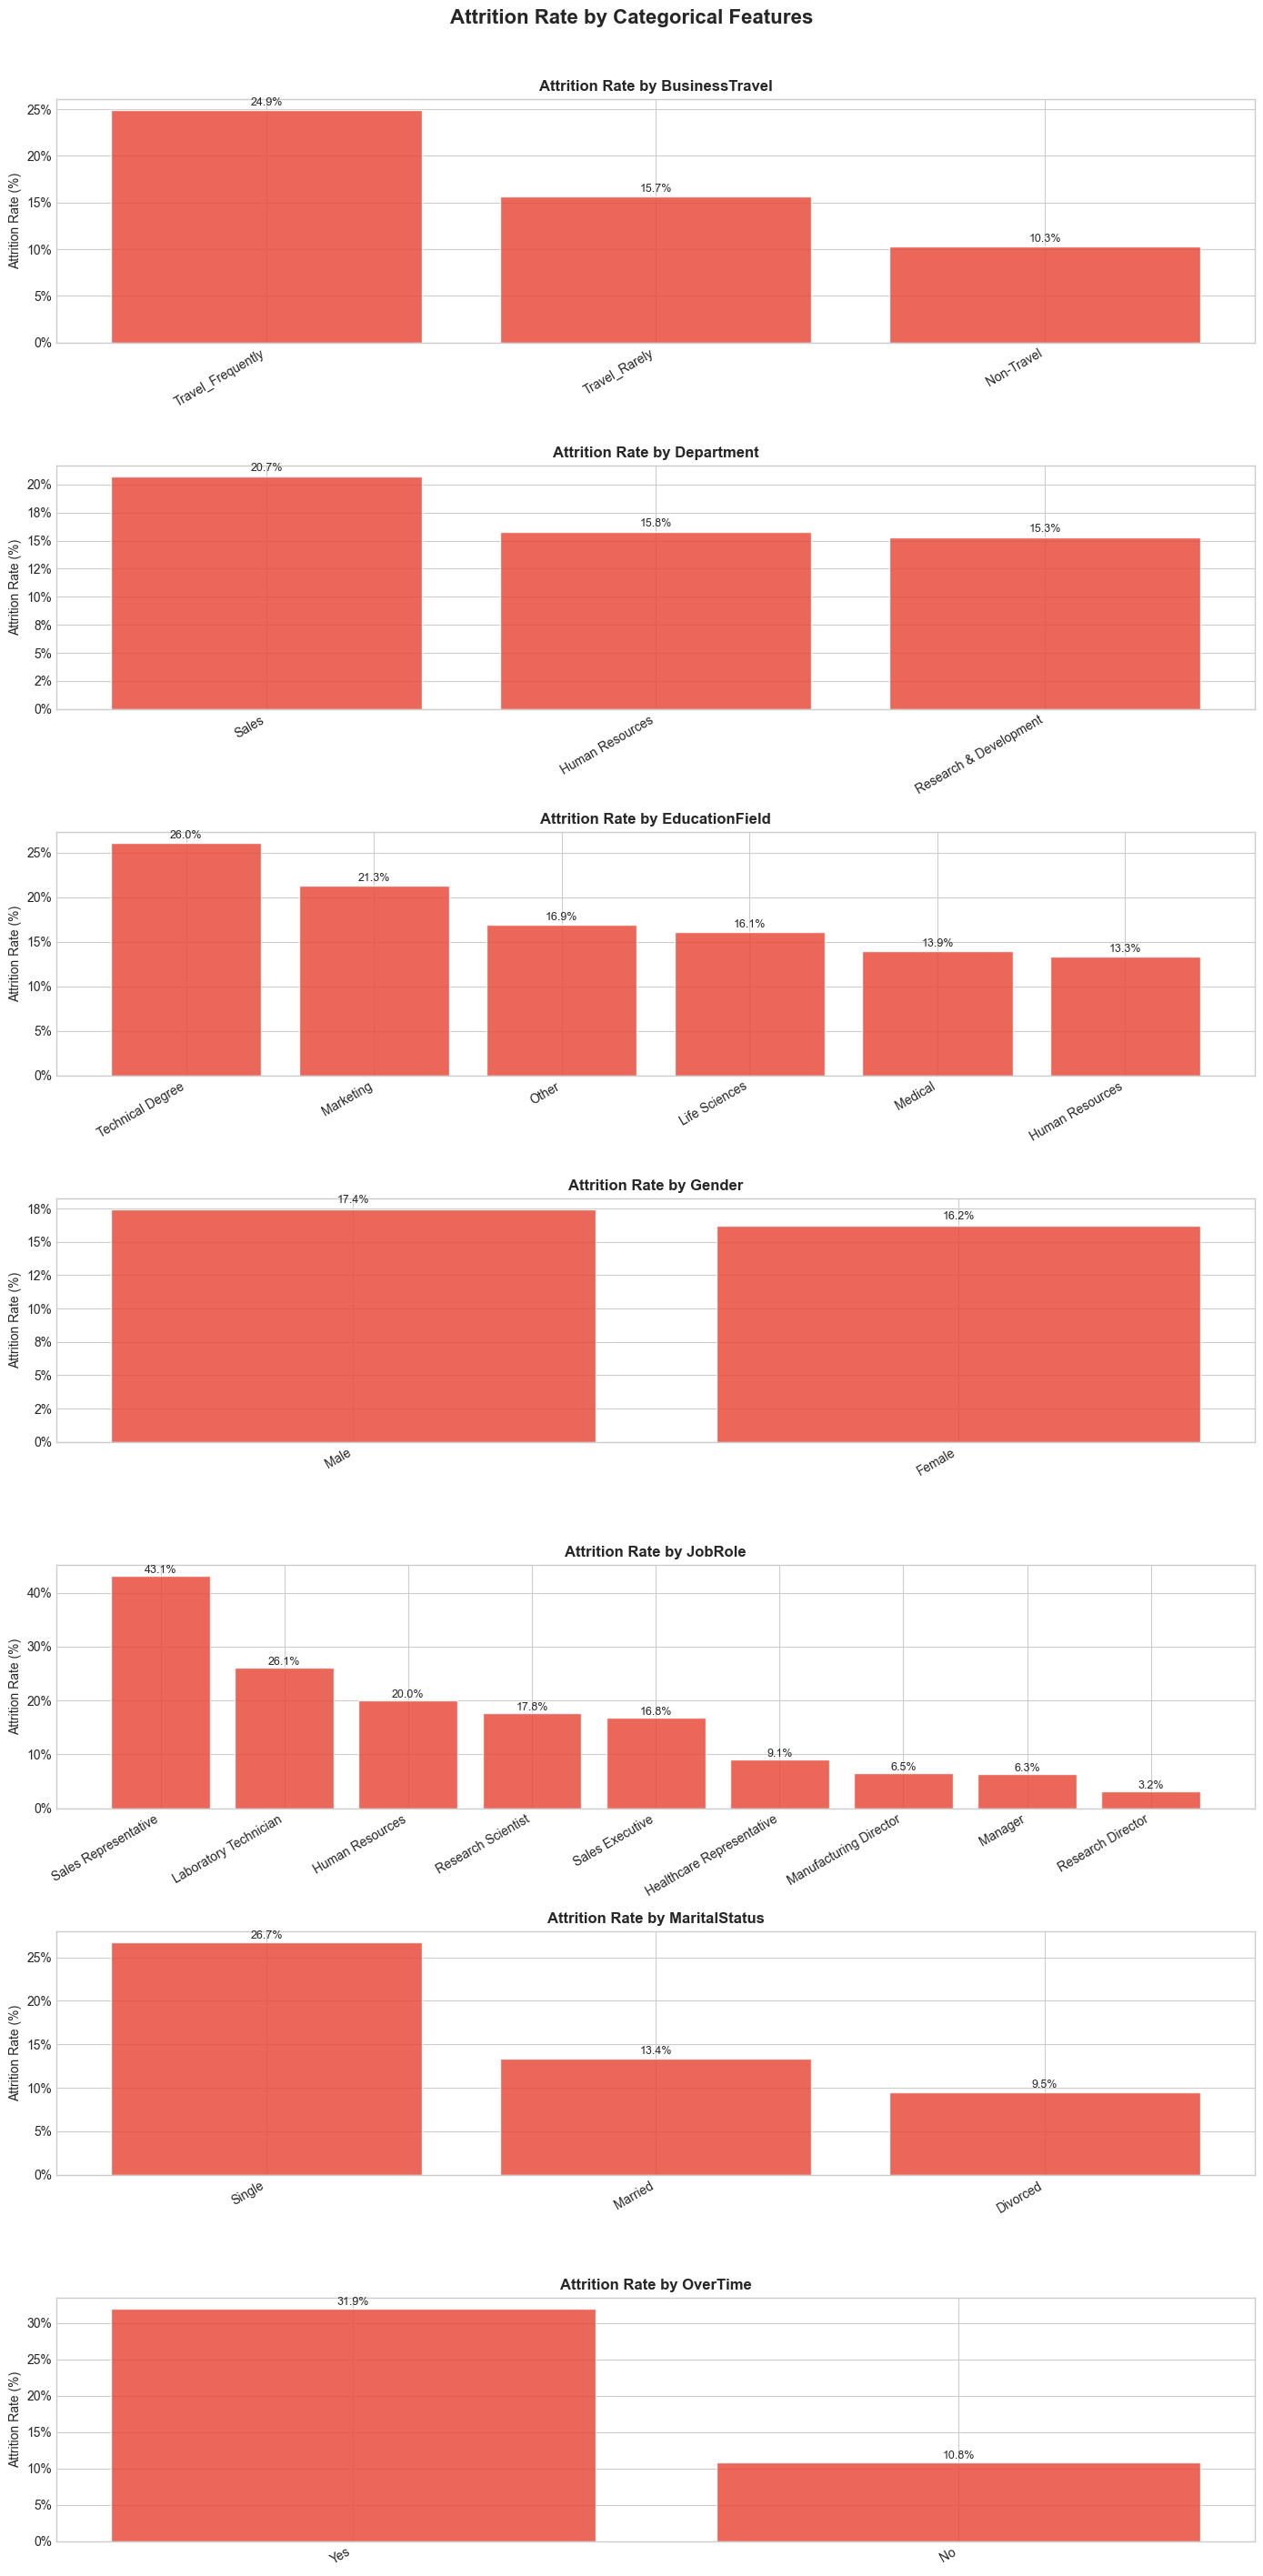

In [12]:
cat_cols = df_labeled.select_dtypes(include=['object']).columns.tolist()
cat_cols = [c for c in cat_cols if c not in ['Over18']]

fig, axes = plt.subplots(len(cat_cols), 1, figsize=(14, len(cat_cols) * 4))
if len(cat_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, cat_cols):
    ct = df_labeled.groupby(col)['Attrition'].mean().sort_values(ascending=False) * 100
    bars = ax.bar(ct.index, ct.values, color='#e74c3c', edgecolor='white', alpha=0.85)
    ax.set_title(f'Attrition Rate by {col}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Attrition Rate (%)')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{bar.get_height():.1f}%', ha='center', fontsize=9)
    ax.set_xticklabels(ct.index, rotation=30, ha='right')

plt.suptitle('Attrition Rate by Categorical Features', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot_categorical_attrition.png', dpi=100, bbox_inches='tight')
plt.show()

### 3.4 Key Numerical Features vs Attrition (Box Plots)

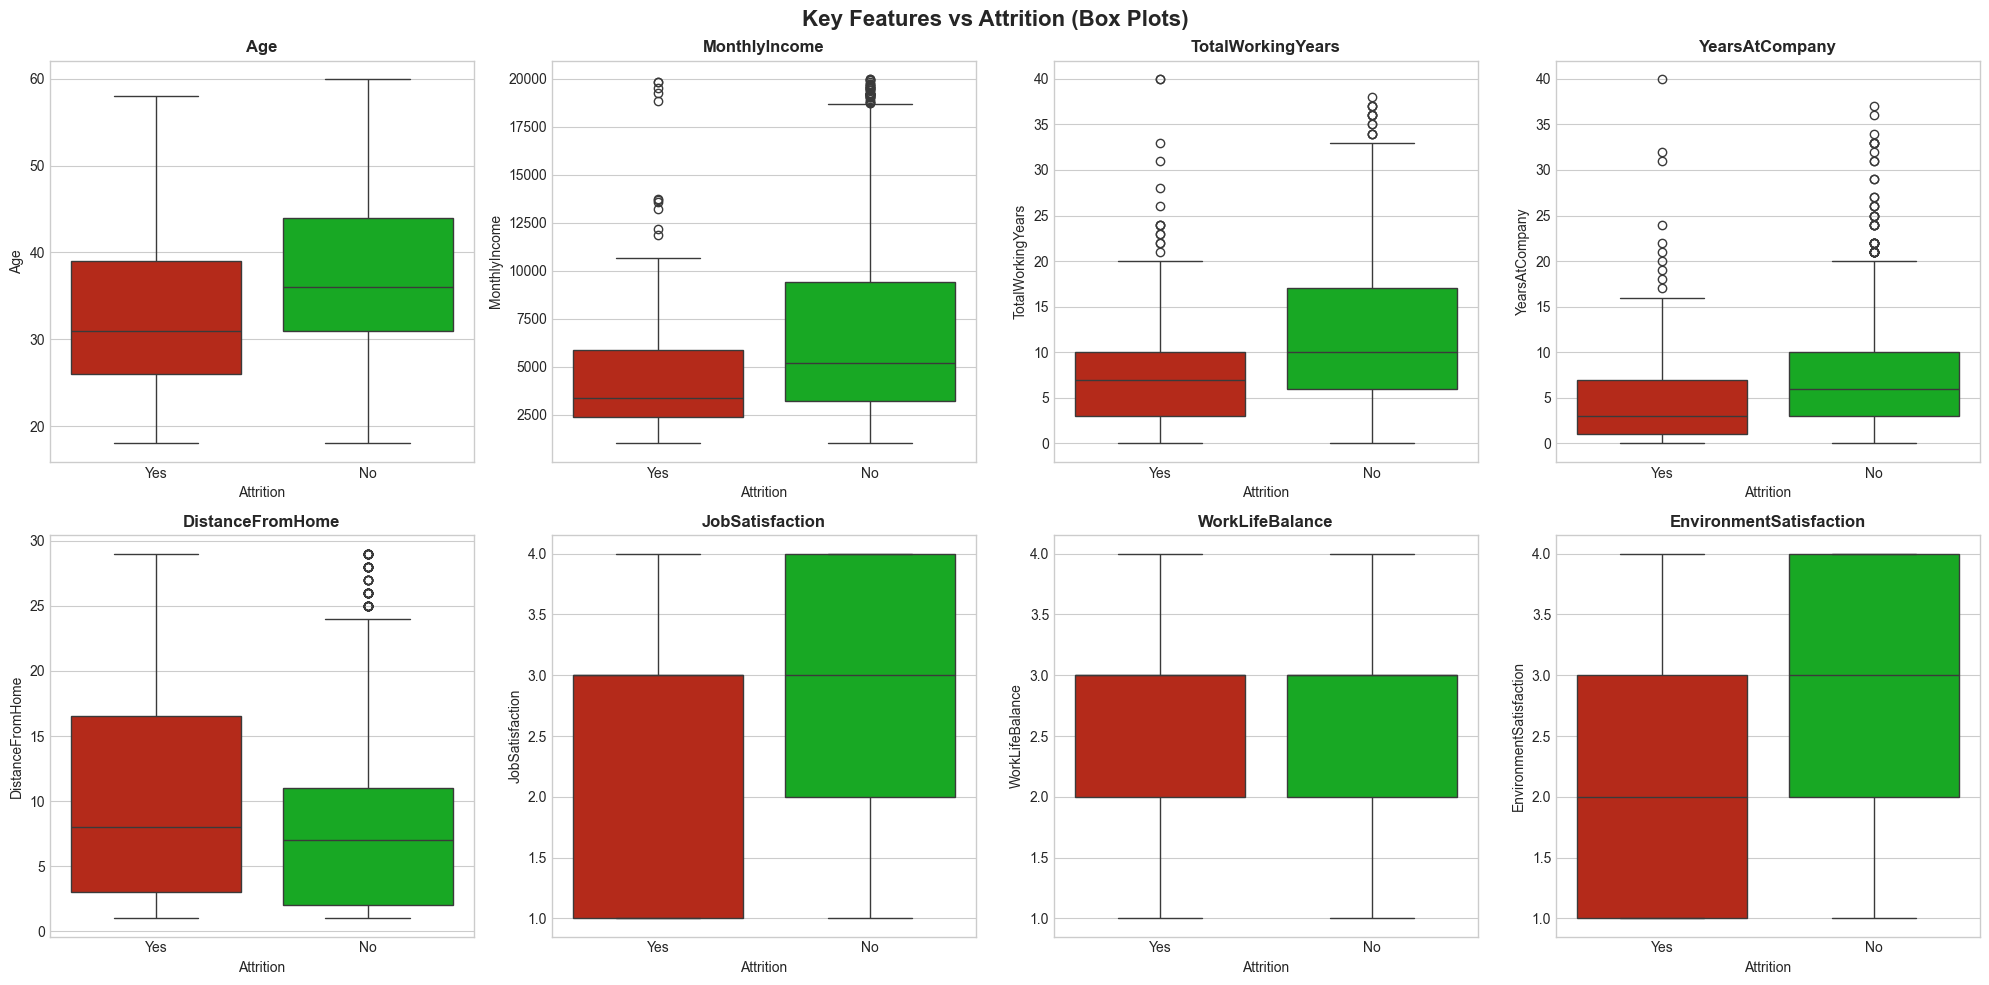

In [ ]:
key_cols = ['Age', 'MonthlyIncome', 'TotalWorkingYears', 'YearsAtCompany',
            'DistanceFromHome', 'JobSatisfaction', 'WorkLifeBalance', 'EnvironmentSatisfaction']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

df_labeled['Attrition_Label'] = df_labeled['Attrition'].map({0.0: 'No', 1.0: 'Yes'})

for i, col in enumerate(key_cols):
    sns.boxplot(data=df_labeled, x='Attrition_Label', y=col, ax=axes[i],
                palette={'No': "#00c010", 'Yes': "#ce1500"})
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Attrition')

plt.suptitle('Key Features vs Attrition (Box Plots)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_boxplots.png', dpi=100, bbox_inches='tight')
plt.show()

### 3.5 Correlation Heatmap

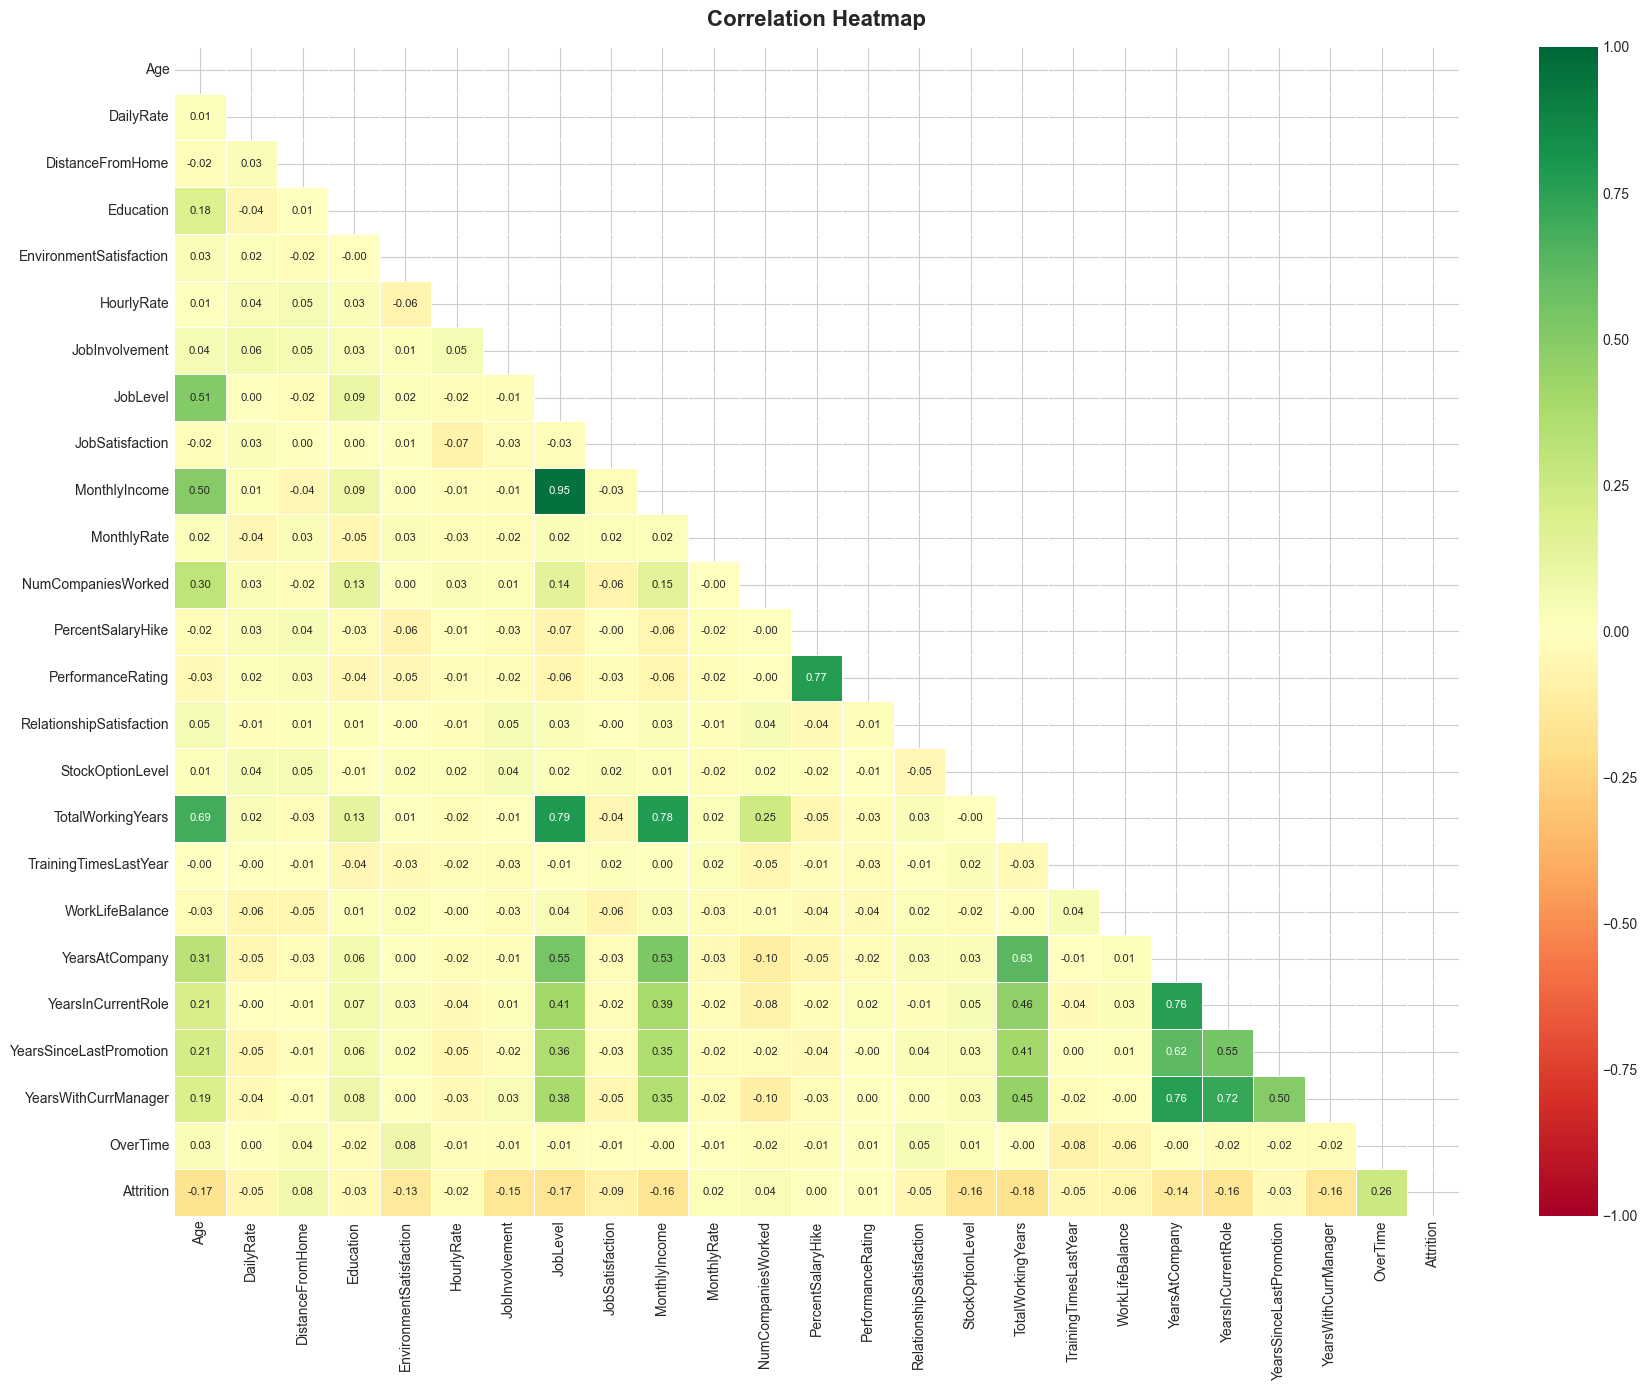

In [14]:
df_labeled['OverTime'] = df_labeled['OverTime'].map({'No': 0, 'Yes': 1})
corr_cols = num_cols + [ 'OverTime', 'Attrition']
corr_matrix = df_labeled[corr_cols].corr()

fig, ax = plt.subplots(figsize=(18, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.5,
            annot_kws={'size': 8})
ax.set_title('Correlation Heatmap', fontsize=16, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('plot_correlation_heatmap.png', dpi=100, bbox_inches='tight')
plt.show()

In [15]:
# Top correlated features with Attrition
attrition_corr = corr_matrix['Attrition'].drop('Attrition').sort_values(key=abs, ascending=False)
print('Top 15 features correlated with Attrition:')
print(attrition_corr.head(15).to_string())

Top 15 features correlated with Attrition:
OverTime                    0.255856
TotalWorkingYears          -0.177137
Age                        -0.172067
JobLevel                   -0.169201
StockOptionLevel           -0.164228
MonthlyIncome              -0.163600
YearsInCurrentRole         -0.158757
YearsWithCurrManager       -0.155962
JobInvolvement             -0.150196
YearsAtCompany             -0.135134
EnvironmentSatisfaction    -0.132848
JobSatisfaction            -0.091751
DistanceFromHome            0.078074
WorkLifeBalance            -0.059556
RelationshipSatisfaction   -0.053417


---
## 4. Data Preprocessing

In [16]:
# Work only with labeled data
df_model = df_labeled.copy()

# Drop useless columns
drop_cols = ['EmployeeId', 'EmployeeCount', 'StandardHours', 'Over18', 'Attrition_Label']
df_model.drop(columns=[c for c in drop_cols if c in df_model.columns], inplace=True)

print(f'Shape after dropping useless columns: {df_model.shape}')
print('Remaining columns:', list(df_model.columns))

Shape after dropping useless columns: (1058, 31)
Remaining columns: ['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [17]:
# Encode categorical features
cat_features = df_model.select_dtypes(include='object').columns.tolist()
print('Categorical features to encode:', cat_features)

le_dict = {}
for col in cat_features:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    le_dict[col] = le

print('Encoding complete.')

Categorical features to encode: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus']
Encoding complete.


In [18]:
# Separate features and target
X = df_model.drop(columns=['Attrition'])
y = df_model['Attrition'].astype(int)

print(f'Features shape: {X.shape}')
print(f'Target distribution:\n{y.value_counts()}')

Features shape: (1058, 30)
Target distribution:
Attrition
0    879
1    179
Name: count, dtype: int64


In [19]:
# Train-test split (stratified to preserve class ratio)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train size: {X_train.shape[0]}')
print(f'Test size:  {X_test.shape[0]}')
print(f'Train attrition rate: {y_train.mean()*100:.1f}%')
print(f'Test  attrition rate: {y_test.mean()*100:.1f}%')

Train size: 846
Test size:  212
Train attrition rate: 16.9%
Test  attrition rate: 17.0%


In [20]:
# Feature scaling for models that need it
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('Scaling complete.')

Scaling complete.


---
## 5. Modeling

In [21]:
# Define models
# Note: class_weight='balanced' helps handle class imbalance
models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(class_weight='balanced', max_depth=6, random_state=42),
    'Random Forest':       RandomForestClassifier(class_weight='balanced', n_estimators=200, max_depth=10, random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=200, max_depth=5, learning_rate=0.05, random_state=42),
    'XGBoost':             XGBClassifier(scale_pos_weight=y_train.value_counts()[0]/y_train.value_counts()[1],
                                         n_estimators=200, max_depth=6, learning_rate=0.05,
                                         use_label_encoder=False, eval_metric='logloss', random_state=42)
}

# Cross-validation (5-fold stratified)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

print('Running 5-fold stratified cross-validation...')
for name, model in models.items():
    X_input = X_train_scaled if name in ['Logistic Regression', 'SVM'] else X_train
    scores = cross_val_score(model, X_input, y_train, cv=cv, scoring='roc_auc')
    cv_results[name] = scores
    print(f'{name:25s} | AUC: {scores.mean():.4f} ± {scores.std():.4f}')

Running 5-fold stratified cross-validation...
Logistic Regression       | AUC: 0.8024 ± 0.0380
Decision Tree             | AUC: 0.6492 ± 0.0335
Random Forest             | AUC: 0.7788 ± 0.0372
Gradient Boosting         | AUC: 0.7570 ± 0.0350
XGBoost                   | AUC: 0.7648 ± 0.0217


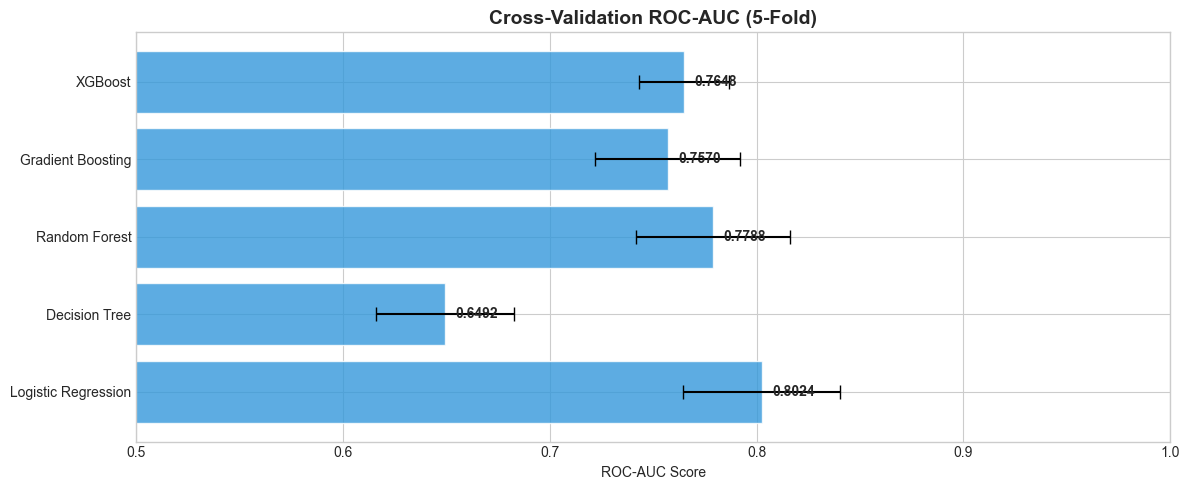

In [22]:
# Plot CV results
fig, ax = plt.subplots(figsize=(12, 5))
model_names = list(cv_results.keys())
means = [cv_results[m].mean() for m in model_names]
stds  = [cv_results[m].std()  for m in model_names]

bars = ax.barh(model_names, means, xerr=stds, color='#3498db', alpha=0.8,
               edgecolor='white', capsize=5)
ax.set_xlabel('ROC-AUC Score')
ax.set_title('Cross-Validation ROC-AUC (5-Fold)', fontsize=14, fontweight='bold')
ax.set_xlim(0.5, 1.0)

for bar, mean in zip(bars, means):
    ax.text(mean + 0.005, bar.get_y() + bar.get_height()/2,
            f'{mean:.4f}', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('plot_cv_auc.png', dpi=120, bbox_inches='tight')
plt.show()

In [23]:
# Train all models on full training set and evaluate on test set
results = {}
trained_models = {}

for name, model in models.items():
    X_tr = X_train_scaled if name in ['Logistic Regression'] else X_train
    X_ts = X_test_scaled  if name in ['Logistic Regression'] else X_test
    
    model.fit(X_tr, y_train)
    y_pred  = model.predict(X_ts)
    y_proba = model.predict_proba(X_ts)[:, 1]
    
    trained_models[name] = model
    results[name] = {
        'Accuracy':  accuracy_score(y_test, y_pred),
        'F1-Score':  f1_score(y_test, y_pred),
        'ROC-AUC':   roc_auc_score(y_test, y_proba),
        'y_pred':    y_pred,
        'y_proba':   y_proba
    }

print('Training complete!')

Training complete!


---
## 6. Evaluation

In [24]:
# Summary table
summary = pd.DataFrame({
    name: {
        'Accuracy':  f"{r['Accuracy']:.4f}",
        'F1-Score':  f"{r['F1-Score']:.4f}",
        'ROC-AUC':   f"{r['ROC-AUC']:.4f}",
    } for name, r in results.items()
}).T.sort_values('ROC-AUC', ascending=False)

print('=== Model Performance on Test Set ===')
display(summary)

=== Model Performance on Test Set ===


,Accuracy,F1-Score,ROC-AUC
Logistic Regression,0.7406,0.5045,0.8038
Gradient Boosting,0.8632,0.4082,0.8013
Random Forest,0.8443,0.2326,0.7816
XGBoost,0.8255,0.4478,0.7740
Decision Tree,0.6274,0.3471,0.6666


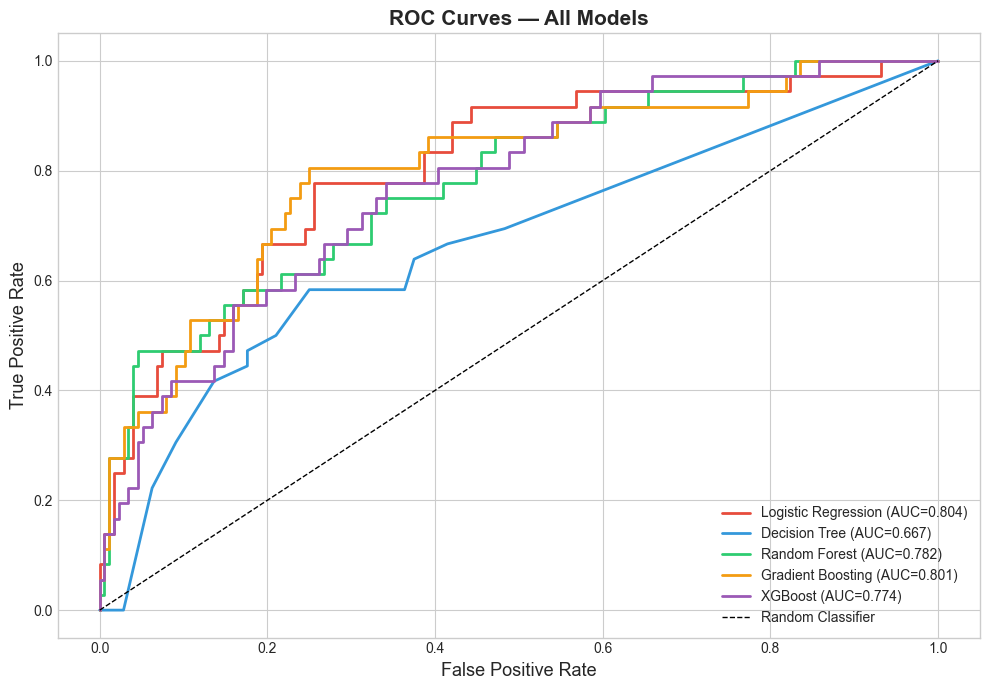

In [25]:
# ROC Curves for all models
fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']

for (name, r), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, r['y_proba'])
    ax.plot(fpr, tpr, label=f"{name} (AUC={r['ROC-AUC']:.3f})", color=color, linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontsize=13)
ax.set_ylabel('True Positive Rate', fontsize=13)
ax.set_title('ROC Curves — All Models', fontsize=15, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.savefig('plot_roc_curves.png', dpi=120, bbox_inches='tight')
plt.show()

In [26]:
# Identify best model by ROC-AUC
best_model_name = max(results, key=lambda k: results[k]['ROC-AUC'])
best_model      = trained_models[best_model_name]
best_result     = results[best_model_name]

print(f'Best model: {best_model_name}')
print(f"ROC-AUC : {best_result['ROC-AUC']:.4f}")
print(f"Accuracy: {best_result['Accuracy']:.4f}")
print(f"F1-Score: {best_result['F1-Score']:.4f}")
print()
print('Classification Report:')
print(classification_report(y_test, best_result['y_pred'],
                             target_names=['No Attrition', 'Attrition']))

Best model: Logistic Regression
ROC-AUC : 0.8038
Accuracy: 0.7406
F1-Score: 0.5045

Classification Report:
              precision    recall  f1-score   support

No Attrition       0.94      0.73      0.82       176
   Attrition       0.37      0.78      0.50        36

    accuracy                           0.74       212
   macro avg       0.66      0.76      0.66       212
weighted avg       0.85      0.74      0.77       212



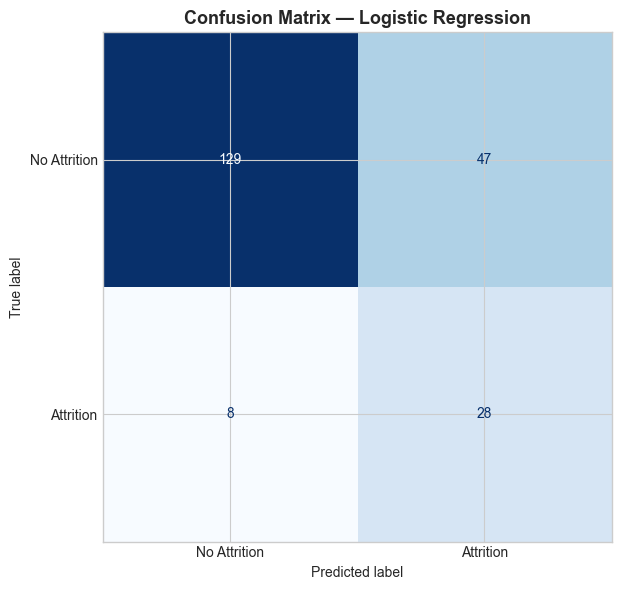

In [27]:
# Confusion matrix for best model
fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_test, best_result['y_pred'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Attrition', 'Attrition'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Confusion Matrix — {best_model_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 7. Feature Importance Analysis

In [28]:
# Feature importance from best tree-based model
# Use Random Forest and XGBoost for comparison
feature_names = X.columns.tolist()

importances_rf  = trained_models['Random Forest'].feature_importances_
importances_xgb = trained_models['XGBoost'].feature_importances_
importances_gb  = trained_models['Gradient Boosting'].feature_importances_

fi_df = pd.DataFrame({
    'Feature':          feature_names,
    'Random Forest':    importances_rf,
    'XGBoost':          importances_xgb,
    'Gradient Boosting': importances_gb
})

# Average importance across models
fi_df['Average Importance'] = fi_df[['Random Forest', 'XGBoost', 'Gradient Boosting']].mean(axis=1)
fi_df = fi_df.sort_values('Average Importance', ascending=False).reset_index(drop=True)

print('Top 15 most important features:')
display(fi_df.head(15))

Top 15 most important features:


,Feature,Random Forest,XGBoost,Gradient Boosting,Average Importance
0,OverTime,0.063395,0.115552,0.082581,0.087176
1,MonthlyIncome,0.071607,0.029765,0.102302,0.067891
2,StockOptionLevel,0.050912,0.086124,0.046438,0.061158
3,Age,0.067934,0.035902,0.074783,0.059540
4,DailyRate,0.055855,0.027385,0.067942,0.050394
5,JobLevel,0.029505,0.089181,0.029370,0.049352
6,TotalWorkingYears,0.053826,0.031247,0.044798,0.043291
7,MonthlyRate,0.050045,0.026298,0.051501,0.042615
8,EnvironmentSatisfaction,0.033720,0.039236,0.047184,0.040047
9,HourlyRate,0.048749,0.022802,0.037577,0.036376


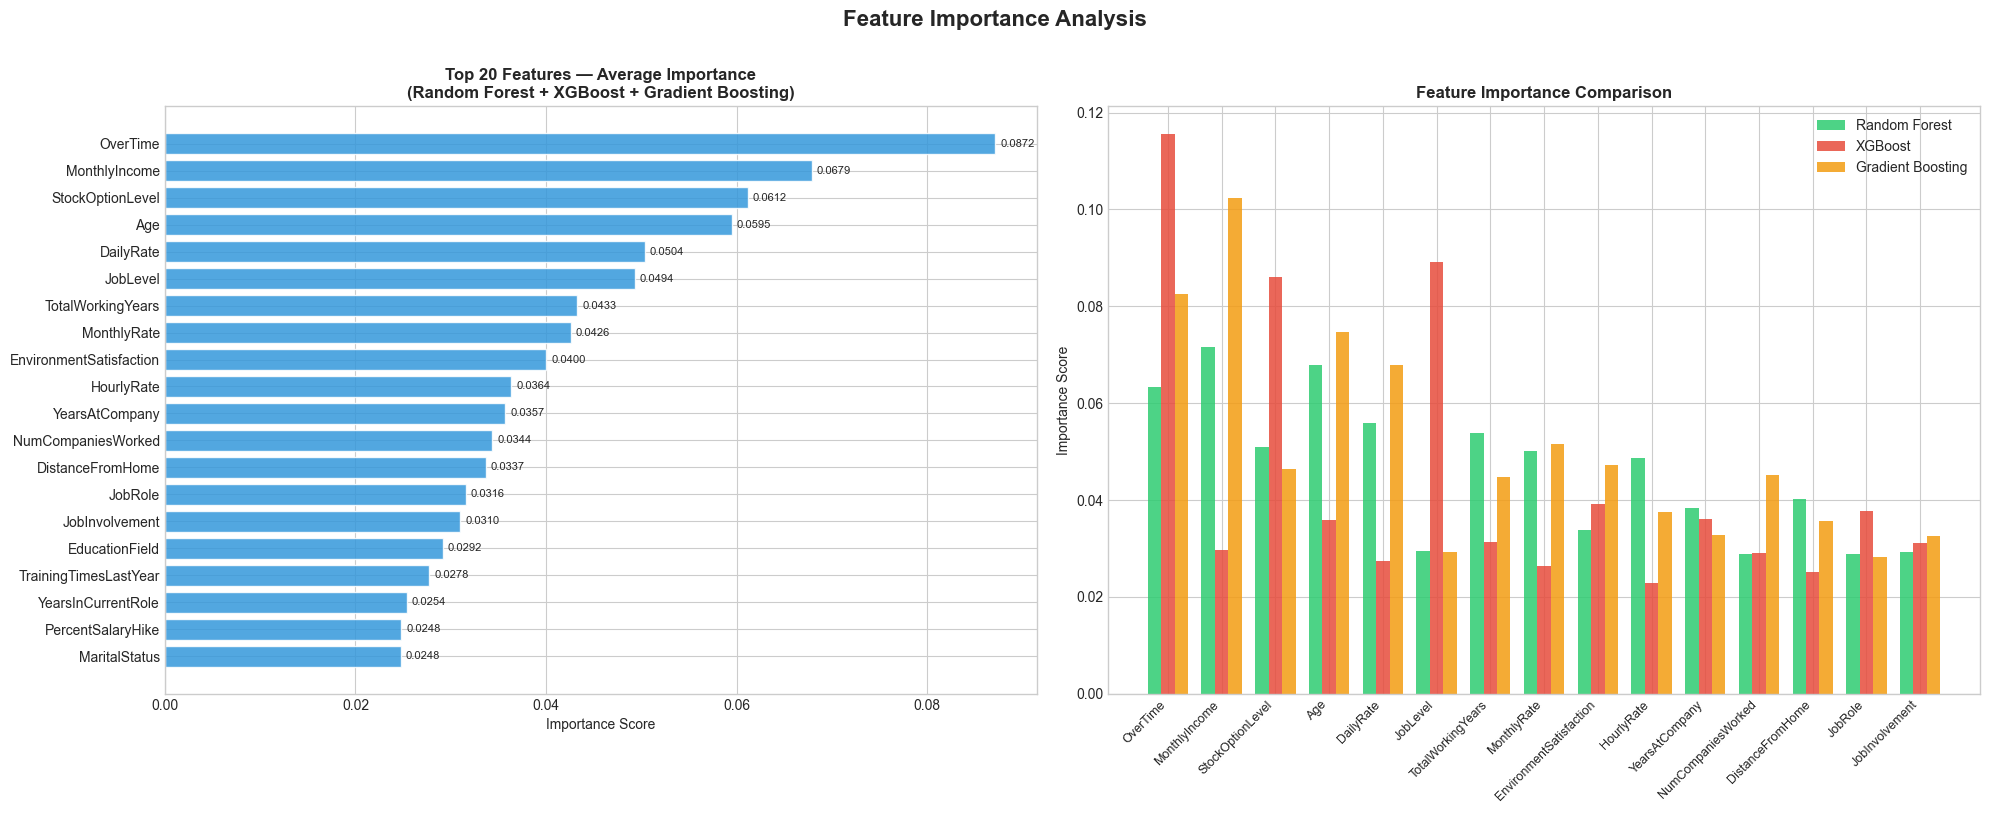

In [29]:
# Plot Feature Importances
top_n = 20
top_fi = fi_df.head(top_n)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Left: Average importance
bars = axes[0].barh(top_fi['Feature'][::-1], top_fi['Average Importance'][::-1],
                    color='#3498db', edgecolor='white', alpha=0.85)
axes[0].set_title(f'Top {top_n} Features — Average Importance\n(Random Forest + XGBoost + Gradient Boosting)',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Importance Score')
for bar in bars:
    axes[0].text(bar.get_width() + 0.0005, bar.get_y() + bar.get_height()/2,
                 f'{bar.get_width():.4f}', va='center', fontsize=8)

# Right: Side-by-side comparison for top 15
top15 = fi_df.head(15)
x = np.arange(len(top15))
width = 0.25
axes[1].bar(x - width, top15['Random Forest'],    width, label='Random Forest',    color='#2ecc71', alpha=0.85)
axes[1].bar(x,          top15['XGBoost'],          width, label='XGBoost',          color='#e74c3c', alpha=0.85)
axes[1].bar(x + width,  top15['Gradient Boosting'], width, label='Gradient Boosting', color='#f39c12', alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(top15['Feature'], rotation=45, ha='right', fontsize=9)
axes[1].set_title('Feature Importance Comparison', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Importance Score')
axes[1].legend()

plt.suptitle('Feature Importance Analysis', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot_feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

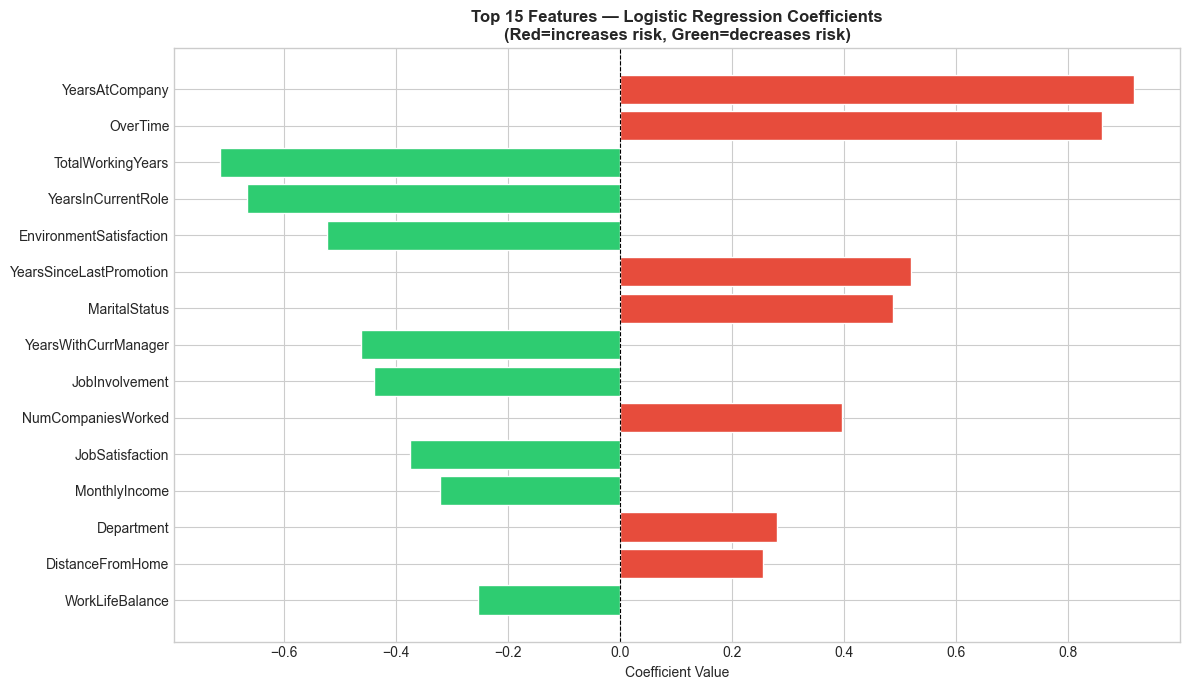

In [30]:
# Feature importance from Logistic Regression (coefficients)
lr_model = trained_models['Logistic Regression']
lr_coef  = pd.DataFrame({
    'Feature':     feature_names,
    'Coefficient': lr_model.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(12, 7))
top15_lr = lr_coef.head(15)
colors_lr = ['#e74c3c' if c > 0 else '#2ecc71' for c in top15_lr['Coefficient']]
ax.barh(top15_lr['Feature'][::-1], top15_lr['Coefficient'][::-1], color=colors_lr[::-1], edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Top 15 Features — Logistic Regression Coefficients\n(Red=increases risk, Green=decreases risk)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Coefficient Value')
plt.tight_layout()
plt.savefig('plot_lr_coefficients.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 8. Summary & Conclusions

In [31]:
print('=' * 60)
print('SUMMARY: Employee Attrition Analysis')
print('=' * 60)
print()
print(f'Dataset: {len(df)} total rows, {len(df_labeled)} labeled rows')
print(f'Features used: {X.shape[1]}')
print()
print('--- Model Performance (Test Set) ---')
for name, r in sorted(results.items(), key=lambda x: x[1]['ROC-AUC'], reverse=True):
    print(f"{name:25s} | Acc={r['Accuracy']:.4f} | F1={r['F1-Score']:.4f} | AUC={r['ROC-AUC']:.4f}")

print()
print(f'--- Best Model: {best_model_name} ---')
print(f"ROC-AUC  = {best_result['ROC-AUC']:.4f}")
print(f"Accuracy = {best_result['Accuracy']:.4f}")
print(f"F1-Score = {best_result['F1-Score']:.4f}")
print()
print('--- Top 10 Critical Factors Influencing Attrition ---')
for i, row in fi_df.head(10).iterrows():
    print(f"{i+1:2d}. {row['Feature']:35s} (importance={row['Average Importance']:.4f})")

SUMMARY: Employee Attrition Analysis

Dataset: 1470 total rows, 1058 labeled rows
Features used: 30

--- Model Performance (Test Set) ---
Logistic Regression       | Acc=0.7406 | F1=0.5045 | AUC=0.8038
Gradient Boosting         | Acc=0.8632 | F1=0.4082 | AUC=0.8013
Random Forest             | Acc=0.8443 | F1=0.2326 | AUC=0.7816
XGBoost                   | Acc=0.8255 | F1=0.4478 | AUC=0.7740
Decision Tree             | Acc=0.6274 | F1=0.3471 | AUC=0.6666

--- Best Model: Logistic Regression ---
ROC-AUC  = 0.8038
Accuracy = 0.7406
F1-Score = 0.5045

--- Top 10 Critical Factors Influencing Attrition ---
 1. OverTime                            (importance=0.0872)
 2. MonthlyIncome                       (importance=0.0679)
 3. StockOptionLevel                    (importance=0.0612)
 4. Age                                 (importance=0.0595)
 5. DailyRate                           (importance=0.0504)
 6. JobLevel                            (importance=0.0494)
 7. TotalWorkingYears           

---
## 9. Wawasan Bisnis & Rekomendasi

Berdasarkan analisis feature importance, **faktor-faktor kritis yang mempengaruhi attrition karyawan** adalah:

### 🔴 High-Risk Factors (Increase Attrition):
1. **OverTime (Lembur)** — Karyawan yang bekerja lembur secara signifikan lebih cenderung untuk keluar. *Rekomendasi: Pantau jam lembur dan tetapkan batasan keseimbangan kerja-kehidupan.*
2. **Low Monthly Income** — Kompensasi yang kurang memadai mendorong pergantian karyawan. *Rekomendasi: Pastikan gaji kompetitif, terutama untuk jabatan level rendah.*
3. **Low Job Satisfaction** — Karyawan yang tidak terlibat lebih cepat meninggalkan perusahaan. *Rekomendasi: Lakukan survei kepuasan secara berkala dan tindak lanjuti hasilnya.*
4. **Short Tenure / YearsAtCompany** — Karyawan baru memiliki risiko lebih tinggi untuk resign. *Rekomendasi: Perkuat program onboarding dan pengembangan karir awal.*
5. **High Distance From Home** — Perjalanan jauh berkorelasi dengan attrition. *Rekomendasi: Tawarkan opsi kerja jarak jauh atau hybrid.*

### 🟢 Protective Factors (Reduce Attrition):
1. **Level Jabatan Lebih Tinggi** — Karyawan senior cenderung bertahan lebih lama.
2. **Total Tahun Pengalaman Kerja Lebih Banyak** — Karyawan berpengalaman lebih stabil.
3. **Kepuasan Lingkungan/Hubungan Lebih Tinggi** — Budaya kerja yang positif mempertahankan bakat.
4. **Level Opsi Saham** — Insentif finansial mengikat karyawan pada perusahaan.
5. **Lama Bersama Manajer Saat Ini** — Hubungan manajer-karyawan yang kuat mengurangi pergantian.

### 📌 Kesimpulan Utama:
> Intervensi yang paling berdampak untuk mengurangi attrition adalah: **mengurangi lembur wajib, meningkatkan paket kompensasi untuk jabatan junior, berinvestasi dalam program kepuasan karyawan, dan menawarkan pengaturan kerja yang fleksibel.**